In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import esmdmsfunctions
from esmdmsfunctions import *

from popDMS import infer_gamma_range

In [2]:
path="/net/dali/home/barton/dhw28/popDMS/esmDMS/esm_sim_saves"


In [3]:
layer = 1

data = pickle.load(open(os.path.join(path, f"error_bars_layer{layer}.pkl"), "rb"))


In [5]:
data2 = pickle.load(open(os.path.join(path, f"n_rep_error_bars_layer{layer}.pkl"), "rb"))

In [6]:
layer_data_1 = data[2][layer]
layer_data_2 = data2[2][layer]


In [ ]:
joint_sel_coeffs1 = layer_data_1[1]
joint_sel_coeffs2 = layer_data_2[1]
yerr_1 = layer_data_1[3]
yerr_2 = layer_data_2[3]
rep_sel_coeffs_1 = layer_data_1[0] # 3 reps, 640 dimensions
rep_sel_coeffs_2 = layer_data_2[0]

In [12]:
# count the nans in yerr_1 and yerr_2
nans_1 = np.isnan(yerr_1).sum()
nans_2 = np.isnan(yerr_2).sum()
print(f"Number of NaNs in yerr_1: {nans_1}")
print(f"Number of NaNs in yerr_2: {nans_2}")

Number of NaNs in yerr_1: 140
Number of NaNs in yerr_2: 0


In [20]:

import seaborn as sns

sns.set_style('darkgrid')
palette = sns.color_palette('deep')

def plot_layer_error_data(layer, dataname="error_bars"):
    
    data = pickle.load(open(os.path.join(path, f"{dataname}_layer{layer}.pkl"), "rb"))
    layer_data = data[2][layer]
    
    y = layer_data[1]
    yerr = layer_data[3]

    fig, axes = plt.subplots(1, 4, figsize=(26, 6))

    # Plot 1: Original error bars
    x = np.arange(len(y))
    axes[0].errorbar(x, y, yerr=yerr, fmt='o', markersize=4, color=palette[0],
                    ecolor=palette[3], capsize=3, alpha=0.7, elinewidth=1)
    axes[0].set_xlabel('Index', fontsize=12)
    axes[0].set_ylabel('s_joint', fontsize=12)
    axes[0].set_title(f'Error Bars for s_joint — Layer {layer}', fontsize=13, fontweight='bold')

    # Plot 2: Sorted by error bar size
    sorted_indices = np.argsort(yerr)
    y_sorted = y[sorted_indices]
    yerr_sorted = yerr[sorted_indices]
    axes[1].errorbar(np.arange(len(y_sorted)), y_sorted, yerr=yerr_sorted, fmt='o', markersize=4,
                    color=palette[1], ecolor=palette[3], capsize=3, alpha=0.7, elinewidth=1)
    axes[1].set_xlabel('Index (sorted by error bar size)', fontsize=12)
    axes[1].set_ylabel('s_joint', fontsize=12)
    axes[1].set_title(f'Error Bars for s_joint (sorted) — Layer {layer}', fontsize=13, fontweight='bold')

    # Plot 3: Magnitude scatter
    mask = ~np.isnan(yerr) & ~np.isnan(y)
    y_clean = y[mask]
    yerr_clean = yerr[mask]
    sorted_indices_mag = np.argsort(np.abs(y_clean))
    y_mag = np.abs(y_clean[sorted_indices_mag])
    yerr_mag = np.abs(yerr_clean[sorted_indices_mag])
    axes[2].scatter(y_mag, yerr_mag, alpha=0.6, s=20, color=palette[2], edgecolors='white', linewidth=0.3)
    axes[2].set_xlabel('|s_joint|', fontsize=12)
    axes[2].set_ylabel('|error bar|', fontsize=12)
    axes[2].set_title(f'Dimension vs Error Magnitude — Layer {layer}', fontsize=13, fontweight='bold')

    # Plot 4: Log-log with power law fit
    mask_pos = mask & (np.abs(y) > 0) & (np.abs(yerr) > 0)
    y_log = np.abs(y[mask_pos])
    yerr_log = np.abs(yerr[mask_pos])

    axes[3].scatter(y_log, yerr_log, alpha=0.5, s=20, color=palette[4], edgecolors='white', linewidth=0.3)
    axes[3].set_xscale('log')
    axes[3].set_yscale('log')

    # Fit power law: yerr = a * y^b  =>  log(yerr) = log(a) + b*log(y)
    log_y = np.log10(y_log)
    log_yerr = np.log10(yerr_log)
    b, log_a = np.polyfit(log_y, log_yerr, 1)
    a = 10**log_a

    y_fit = np.logspace(np.log10(y_log.min()), np.log10(y_log.max()), 200)
    yerr_fit = a * y_fit**b
    axes[3].plot(y_fit, yerr_fit, color=palette[3], linewidth=2,
                 label=f'Power law: $y = {a:.3g} \\cdot x^{{{b:.2f}}}$')
    axes[3].legend(fontsize=11)
    axes[3].set_xlabel('|s_joint|', fontsize=12)
    axes[3].set_ylabel('|error bar|', fontsize=12)
    axes[3].set_title(f'Log-Log Power Law Fit — Layer {layer}', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

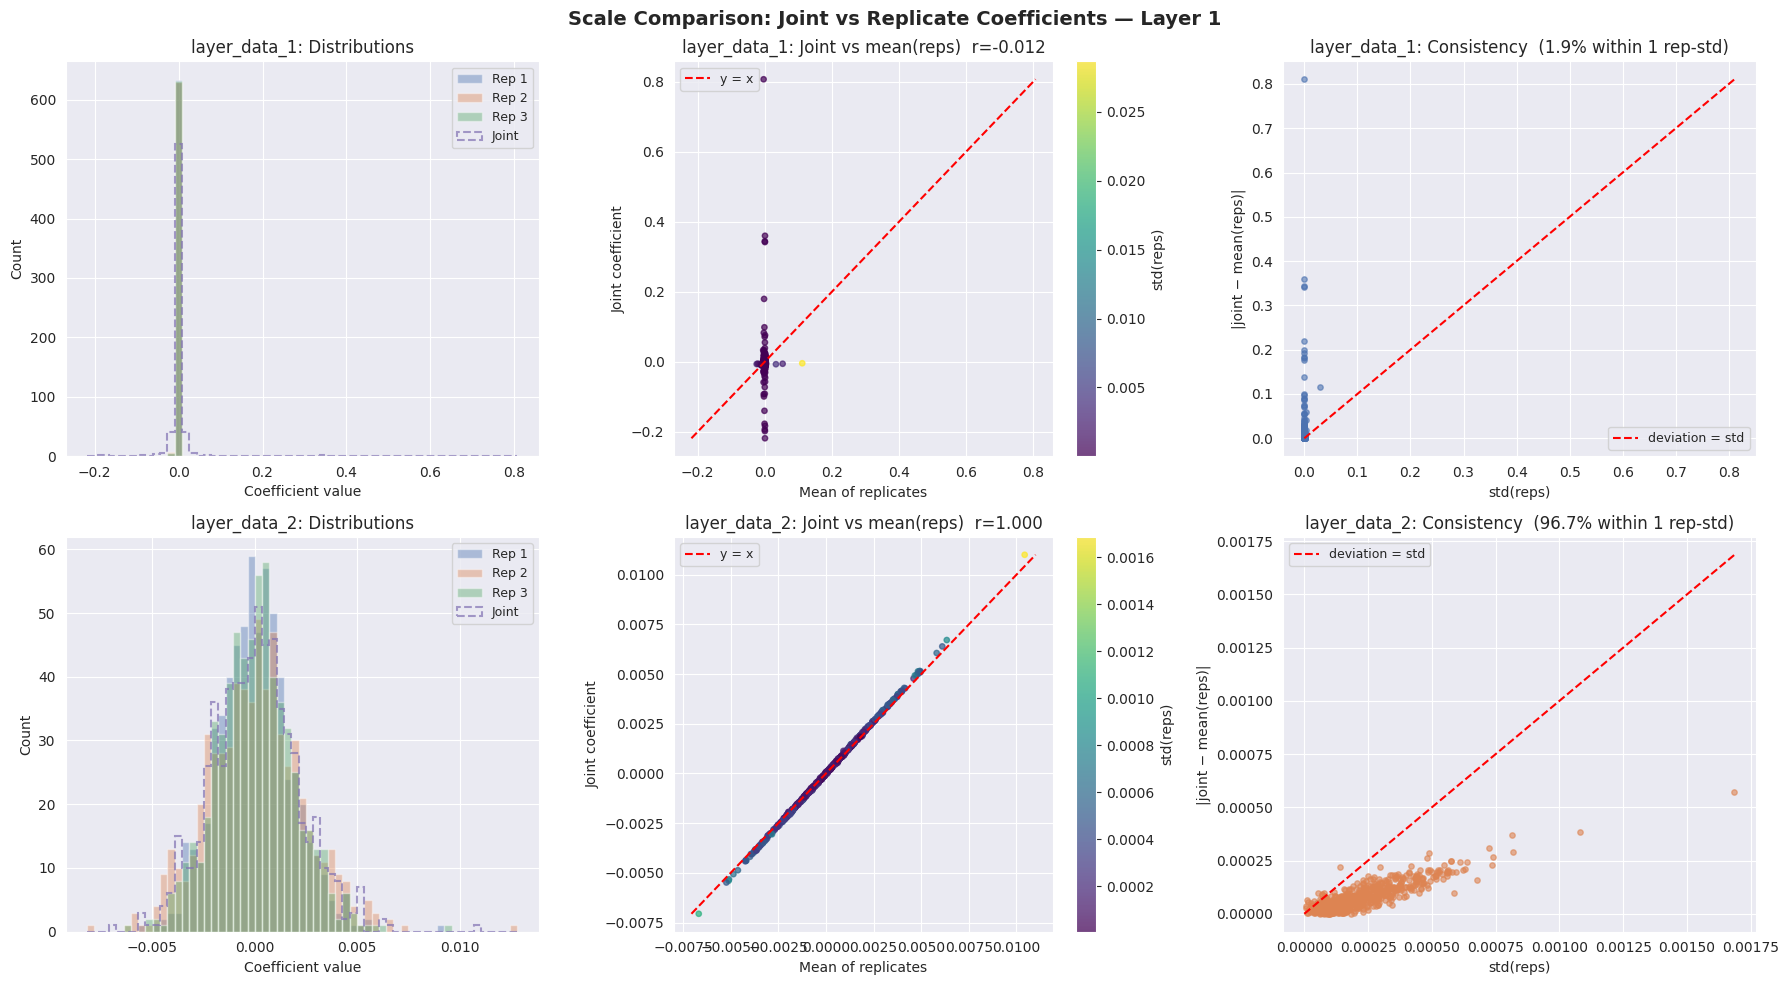


layer_data_1:
  Joint scale (std):           0.0462  |  Rep scale mean(std): 0.0002
  |Joint - mean(reps)| mean:   0.0115  (vs rep std mean: 0.0002)
  Corr(joint, mean(reps)):      -0.0123
  Corr(joint, rep1):          -0.0149
  Corr(joint, rep2):          -0.0096
  Corr(joint, rep3):          -0.0134

layer_data_2:
  Joint scale (std):           0.0021  |  Rep scale mean(std): 0.0002
  |Joint - mean(reps)| mean:   0.0001  (vs rep std mean: 0.0002)
  Corr(joint, mean(reps)):      0.9999
  Corr(joint, rep1):          0.9965
  Corr(joint, rep2):          0.9980
  Corr(joint, rep3):          0.9979


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
palette = sns.color_palette('deep')

rep1 = layer_data_1[0]  # shape (3, 640)
joint1 = layer_data_1[1]  # shape (640,)
rep2 = layer_data_2[0]
joint2 = layer_data_2[1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Scale Comparison: Joint vs Replicate Coefficients — Layer {layer}', fontsize=14, fontweight='bold')

for row, (rep, joint, label) in enumerate([(rep1, joint1, 'layer_data_1'), (rep2, joint2, 'layer_data_2')]):
    ax = axes[row]

    # --- Plot 1: Overlaid histograms ---
    bins = np.linspace(min(joint.min(), rep.min()), max(joint.max(), rep.max()), 60)
    for i in range(rep.shape[0]):
        ax[0].hist(rep[i], bins=bins, alpha=0.4, label=f'Rep {i+1}', color=palette[i])
    ax[0].hist(joint, bins=bins, alpha=0.7, label='Joint', color=palette[4],
               linewidth=1.5, histtype='step', linestyle='--')
    ax[0].set_xlabel('Coefficient value')
    ax[0].set_ylabel('Count')
    ax[0].set_title(f'{label}: Distributions')
    ax[0].legend(fontsize=9)

    # --- Plot 2: Joint vs mean(reps), colored by std(reps) ---
    rep_mean = rep.mean(axis=0)
    rep_std = rep.std(axis=0)
    sc = ax[1].scatter(rep_mean, joint, c=rep_std, cmap='viridis', s=15, alpha=0.7)
    lim = np.array([min(rep_mean.min(), joint.min()), max(rep_mean.max(), joint.max())])
    ax[1].plot(lim, lim, 'r--', linewidth=1.5, label='y = x')
    plt.colorbar(sc, ax=ax[1], label='std(reps)')
    r = np.corrcoef(rep_mean, joint)[0, 1]
    ax[1].set_xlabel('Mean of replicates')
    ax[1].set_ylabel('Joint coefficient')
    ax[1].set_title(f'{label}: Joint vs mean(reps)  r={r:.3f}')
    ax[1].legend(fontsize=9)

    # --- Plot 3: |joint - mean(reps)| vs std(reps) ---
    deviation = np.abs(joint - rep_mean)
    ax[2].scatter(rep_std, deviation, s=15, alpha=0.6, color=palette[row])
    lim2 = np.array([0, max(rep_std.max(), deviation.max())])
    ax[2].plot(lim2, lim2, 'r--', linewidth=1.5, label='deviation = std')
    frac_within_1std = (deviation < rep_std).mean()
    ax[2].set_xlabel('std(reps)')
    ax[2].set_ylabel('|joint − mean(reps)|')
    ax[2].set_title(f'{label}: Consistency  ({frac_within_1std:.1%} within 1 rep-std)')
    ax[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Summary stats
for rep, joint, label in [(rep1, joint1, 'layer_data_1'), (rep2, joint2, 'layer_data_2')]:
    rep_mean = rep.mean(axis=0)
    rep_std = rep.std(axis=0)
    deviation = np.abs(joint - rep_mean)
    print(f"\n{label}:")
    print(f"  Joint scale (std):           {joint.std():.4f}  |  Rep scale mean(std): {rep_std.mean():.4f}")
    print(f"  |Joint - mean(reps)| mean:   {deviation.mean():.4f}  (vs rep std mean: {rep_std.mean():.4f})")
    print(f"  Corr(joint, mean(reps)):      {np.corrcoef(rep_mean, joint)[0,1]:.4f}")
    for i in range(rep.shape[0]):
        print(f"  Corr(joint, rep{i+1}):          {np.corrcoef(rep[i], joint)[0,1]:.4f}")


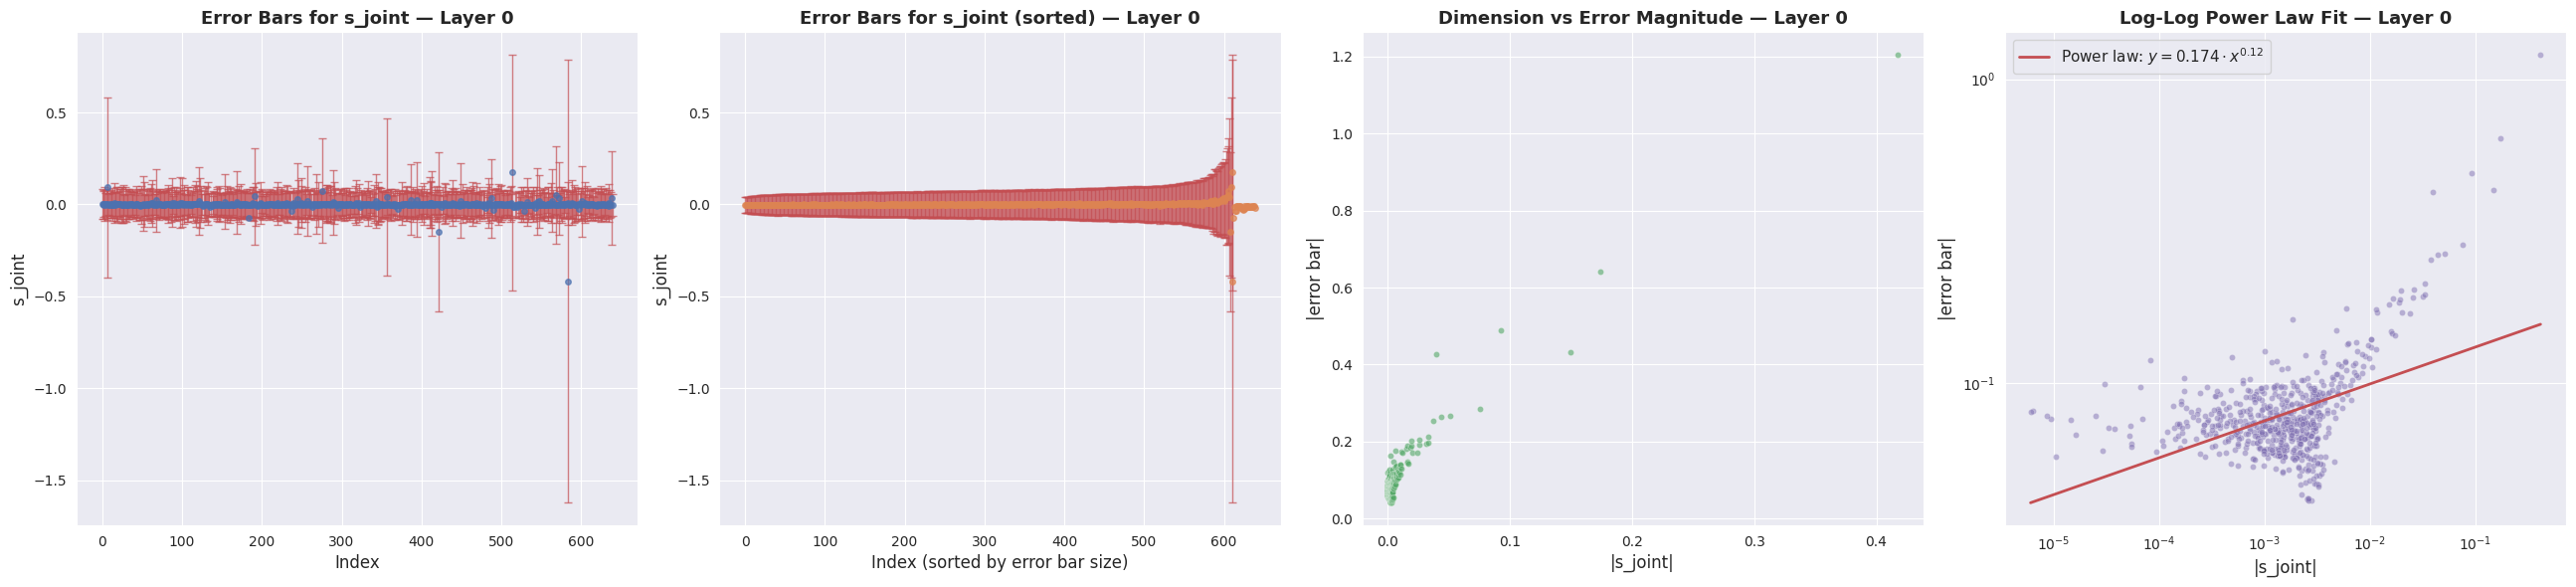

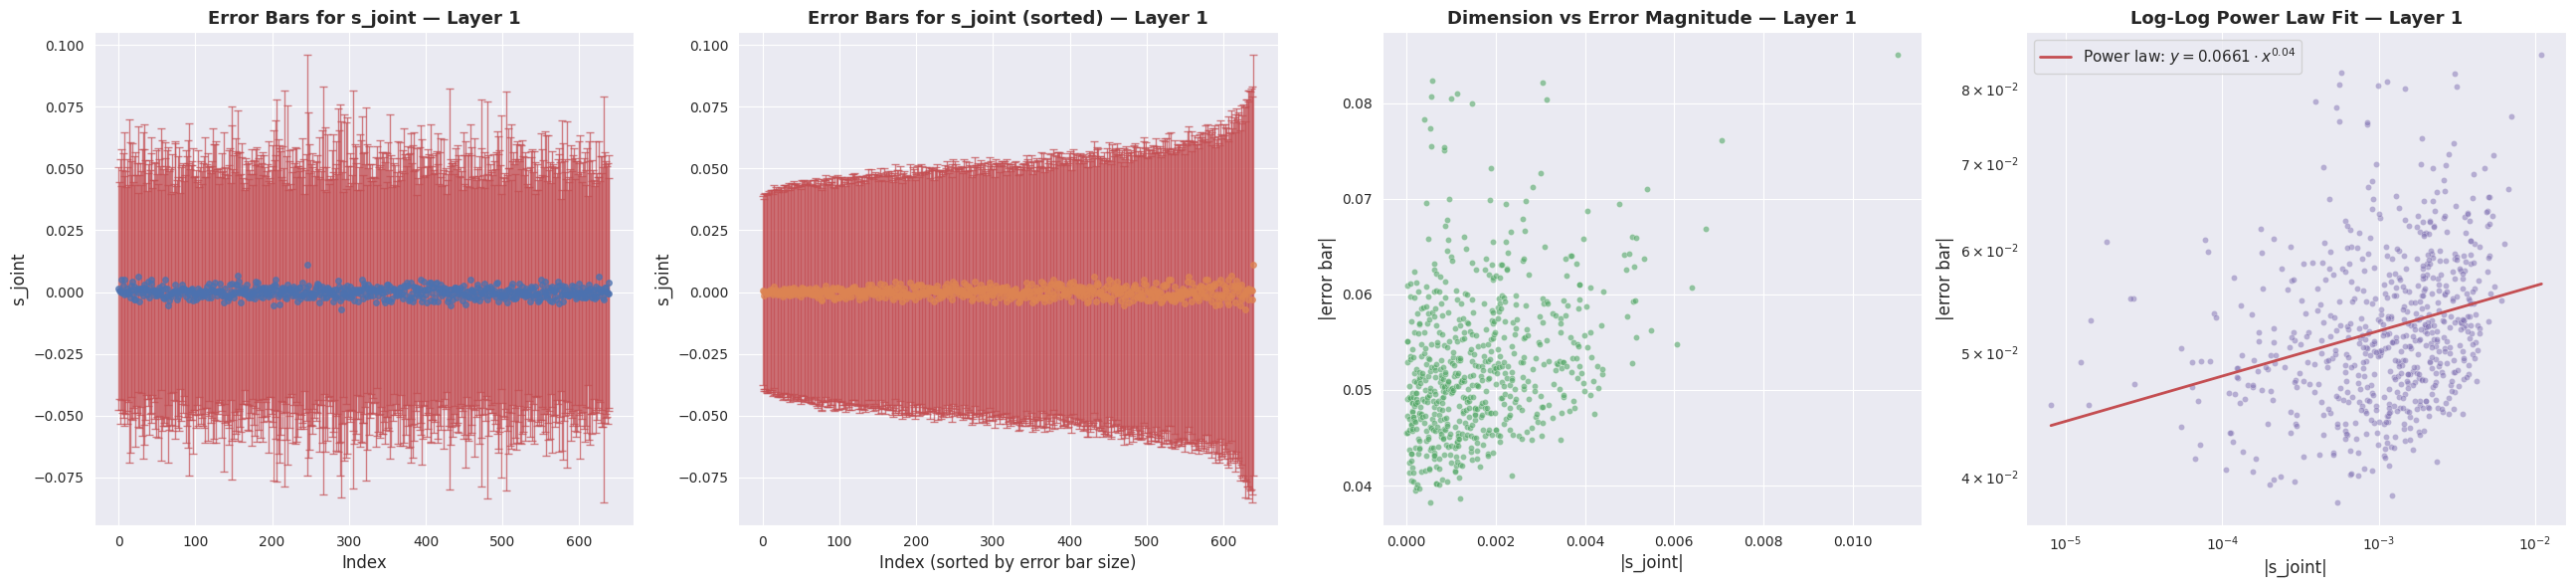

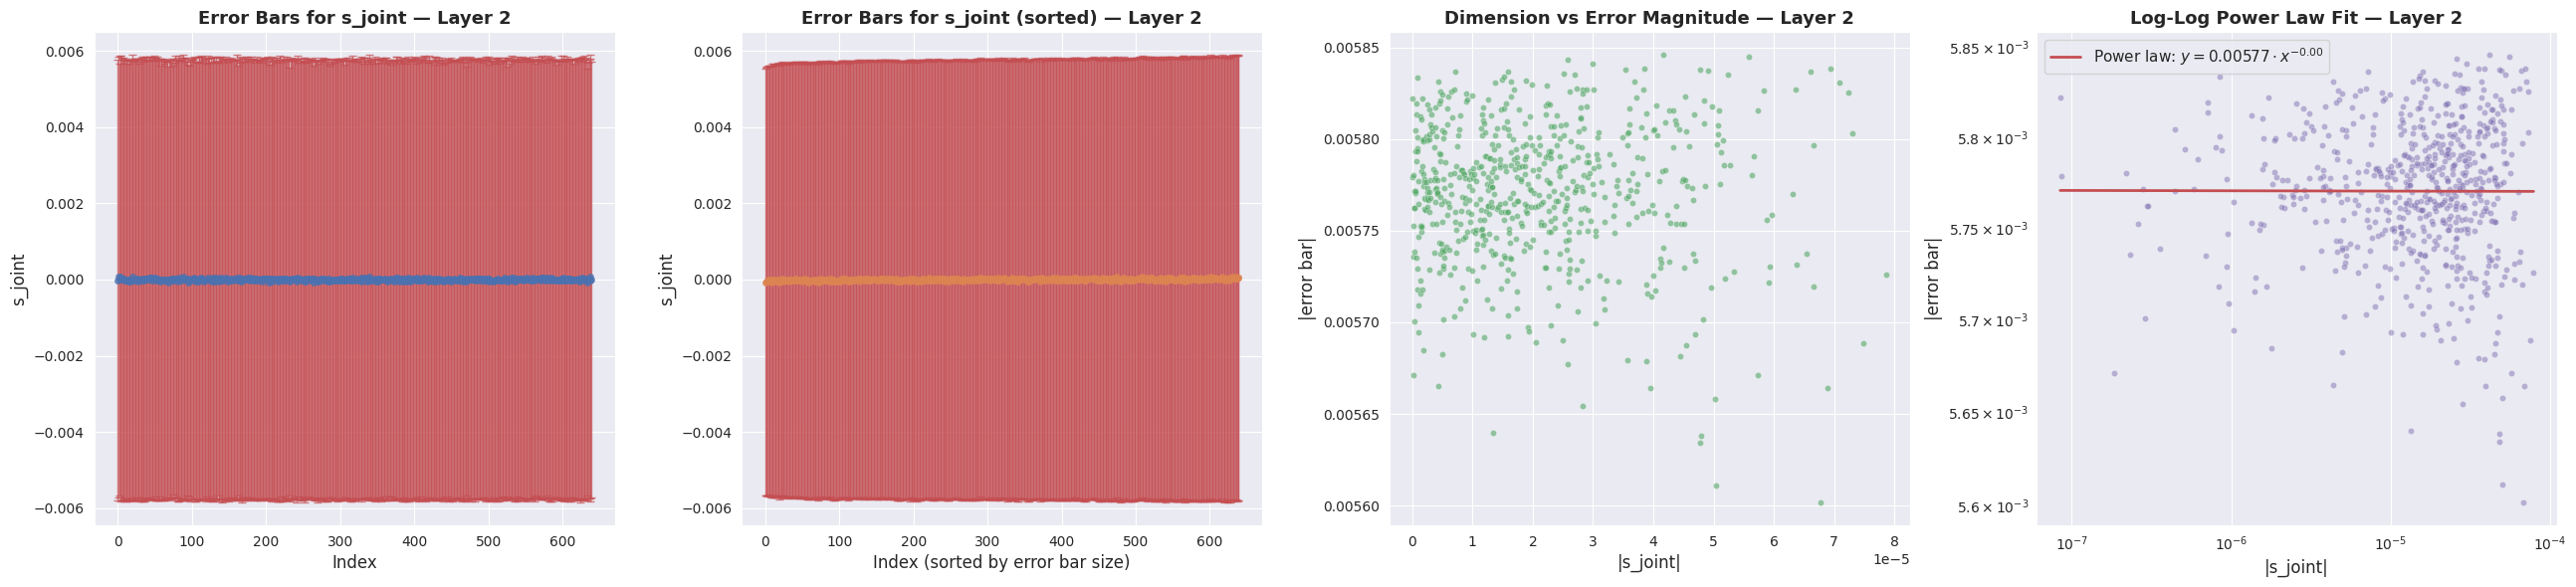

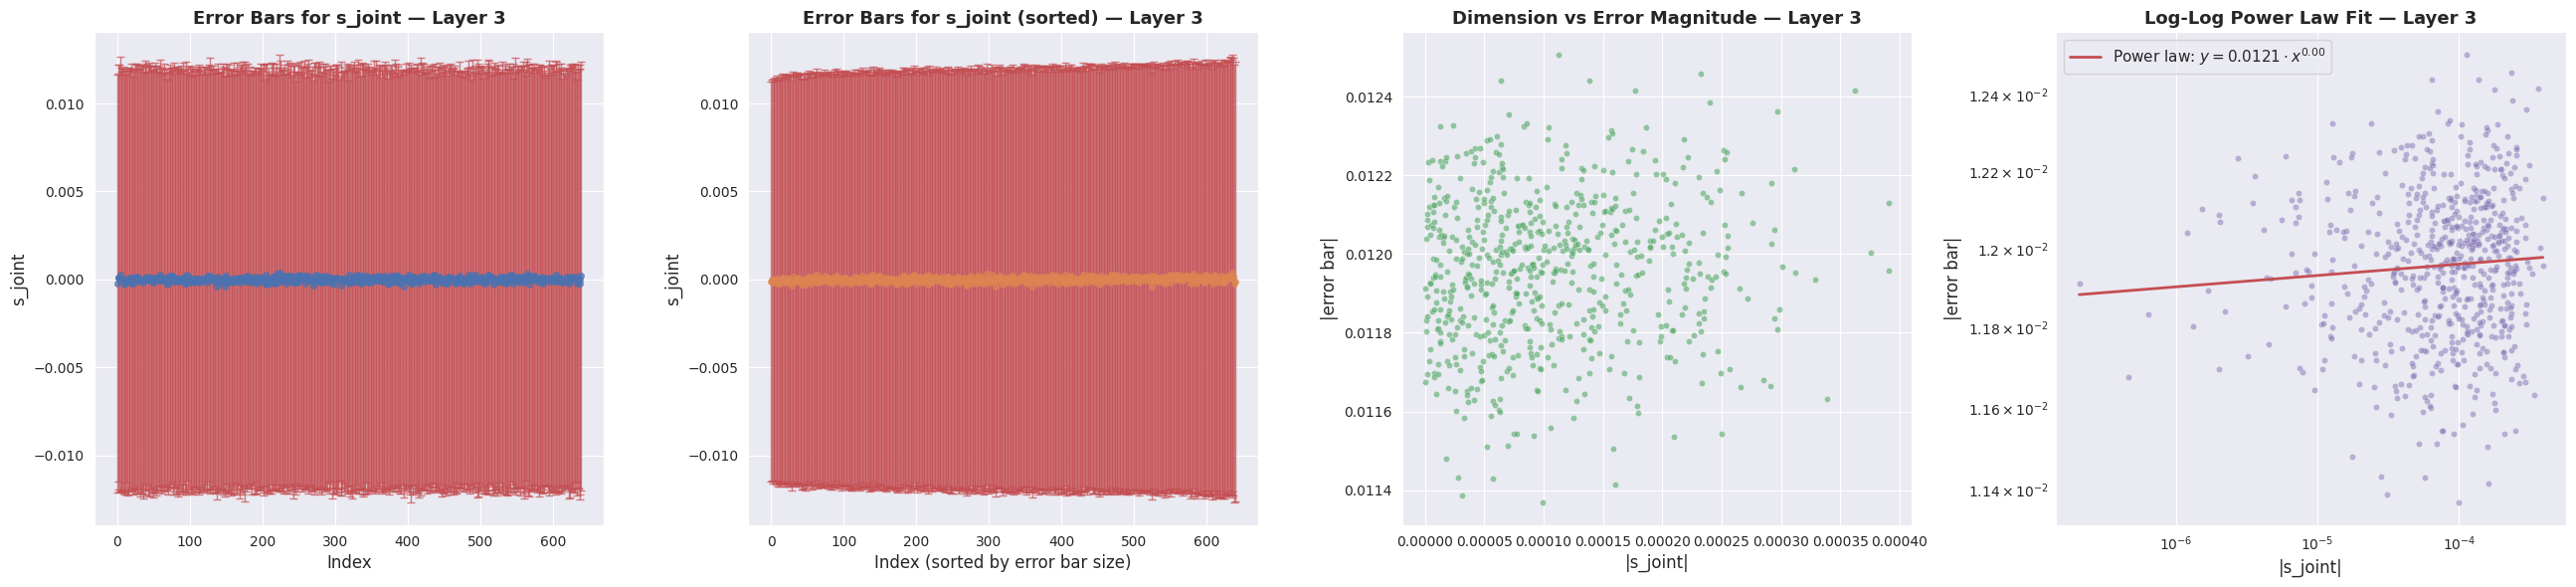

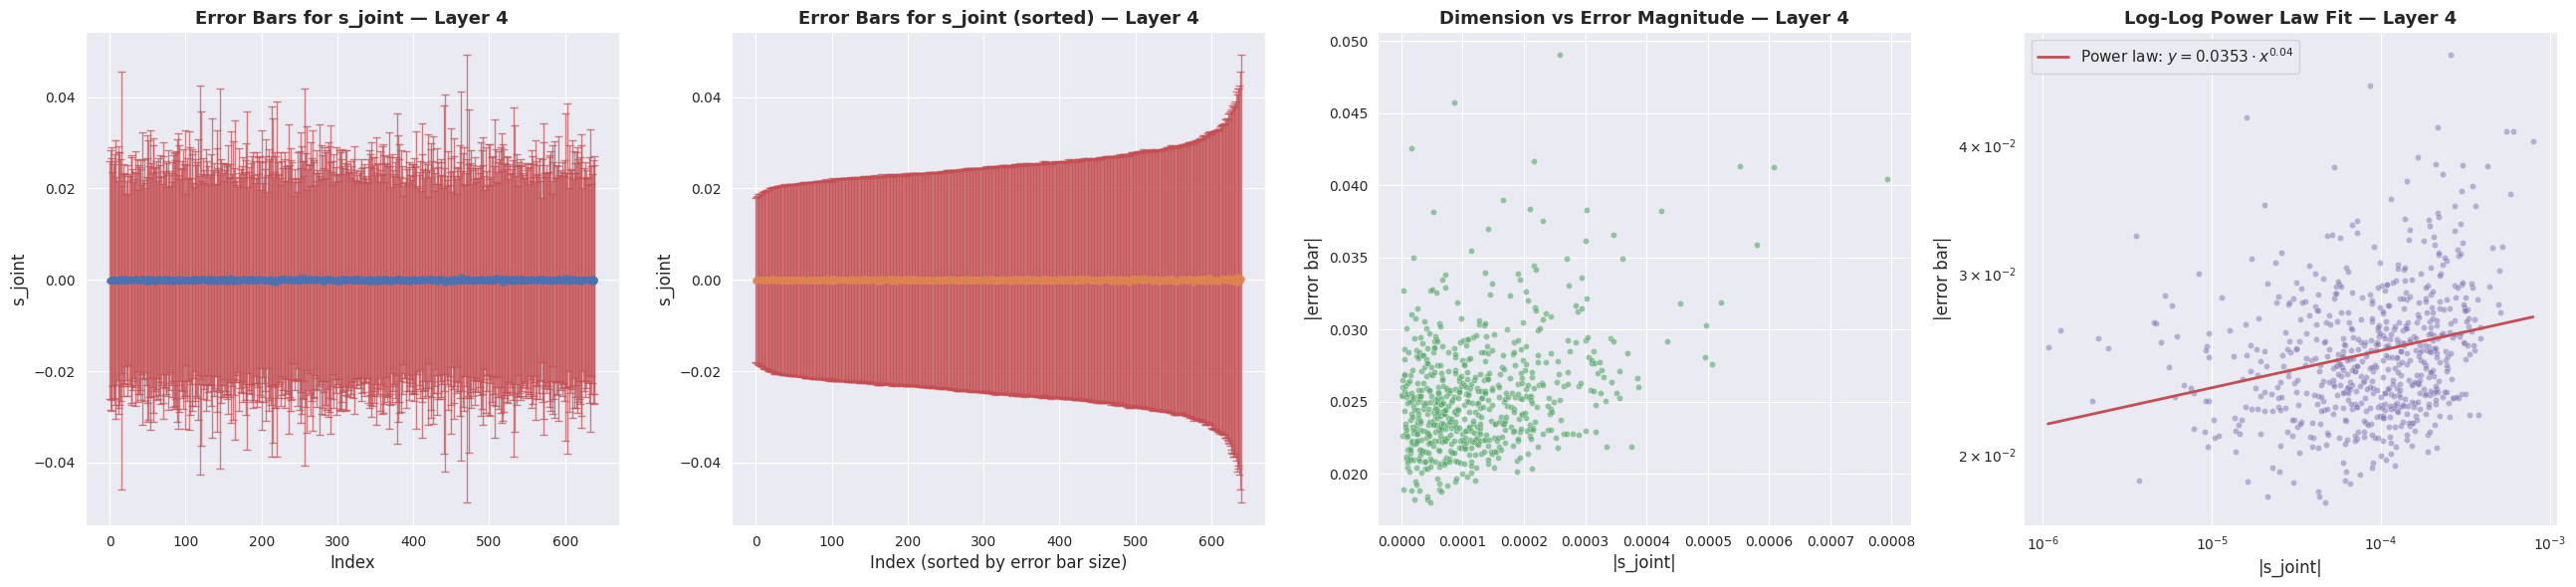

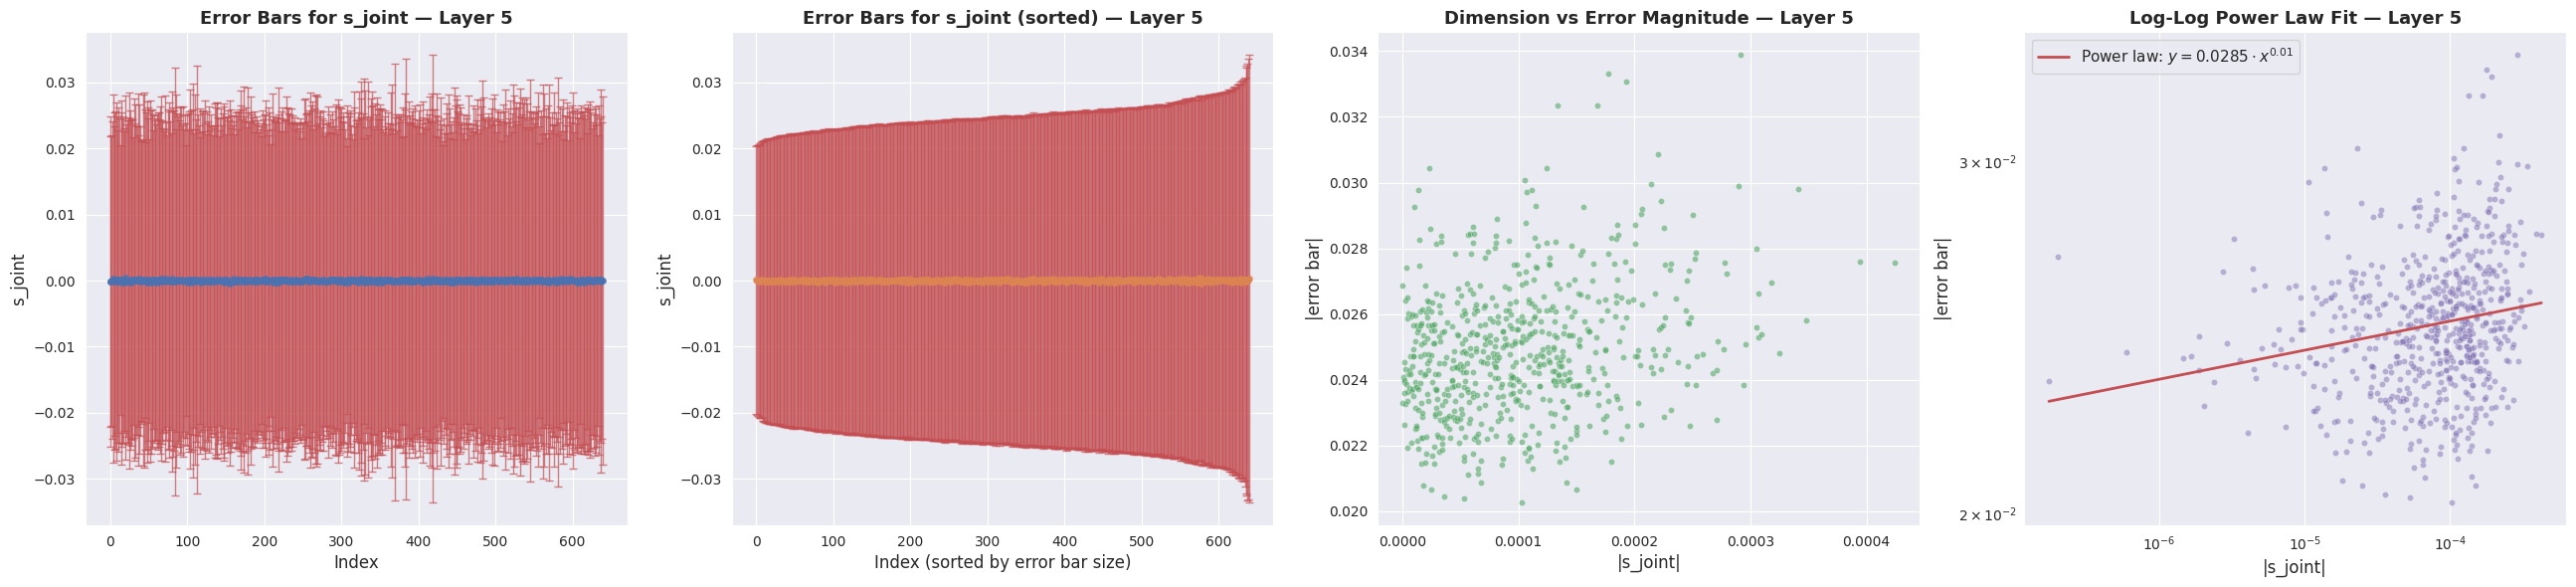

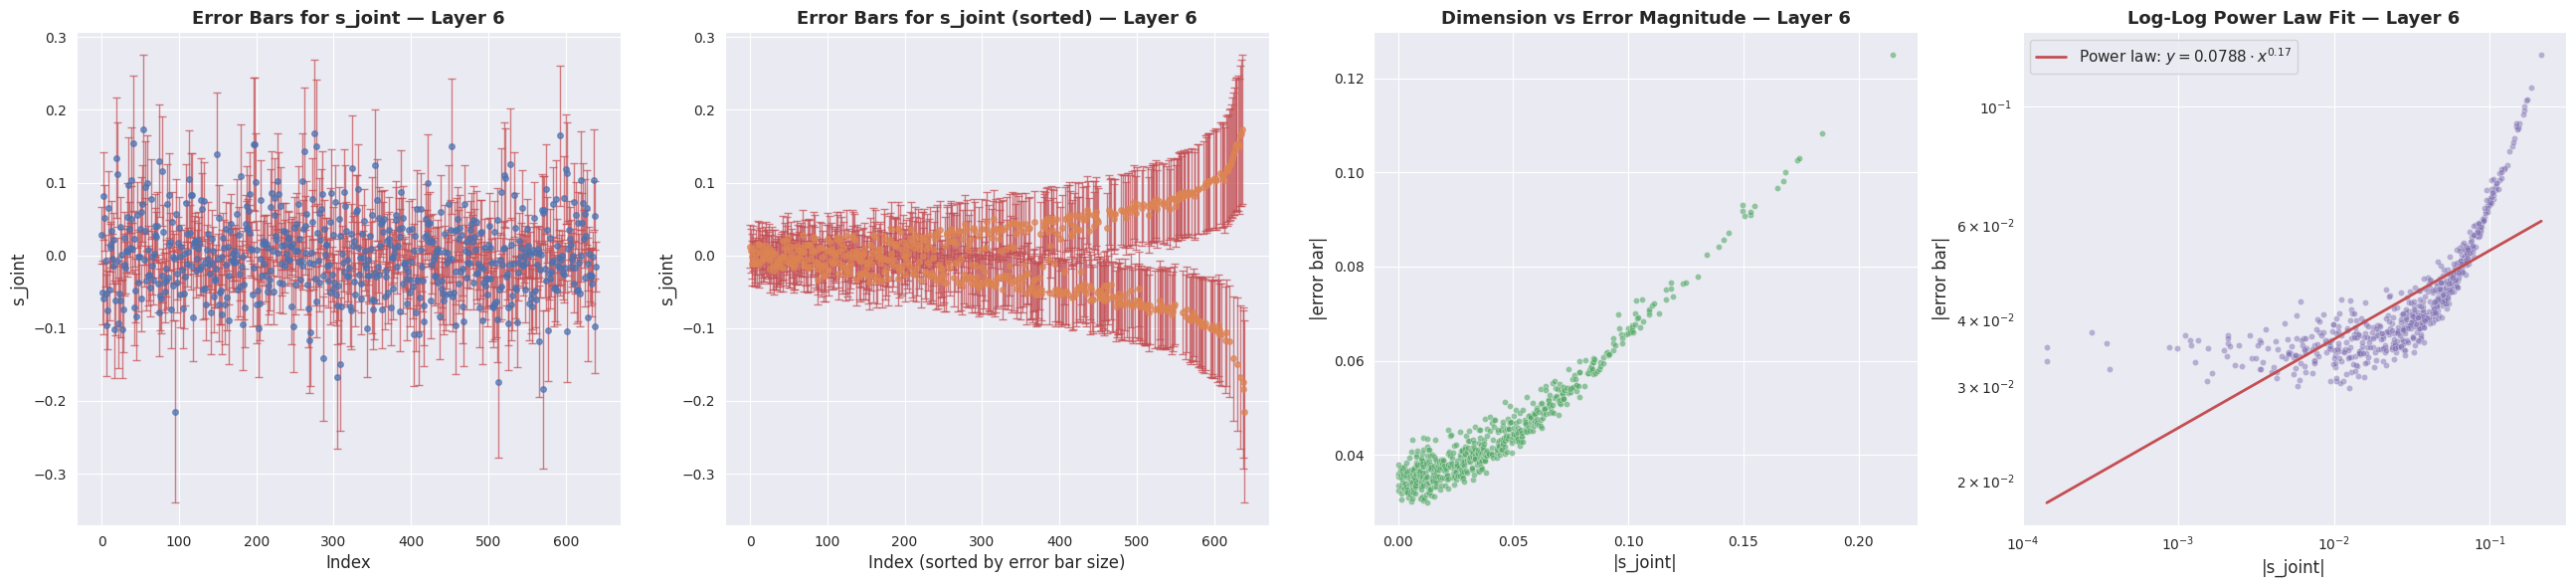

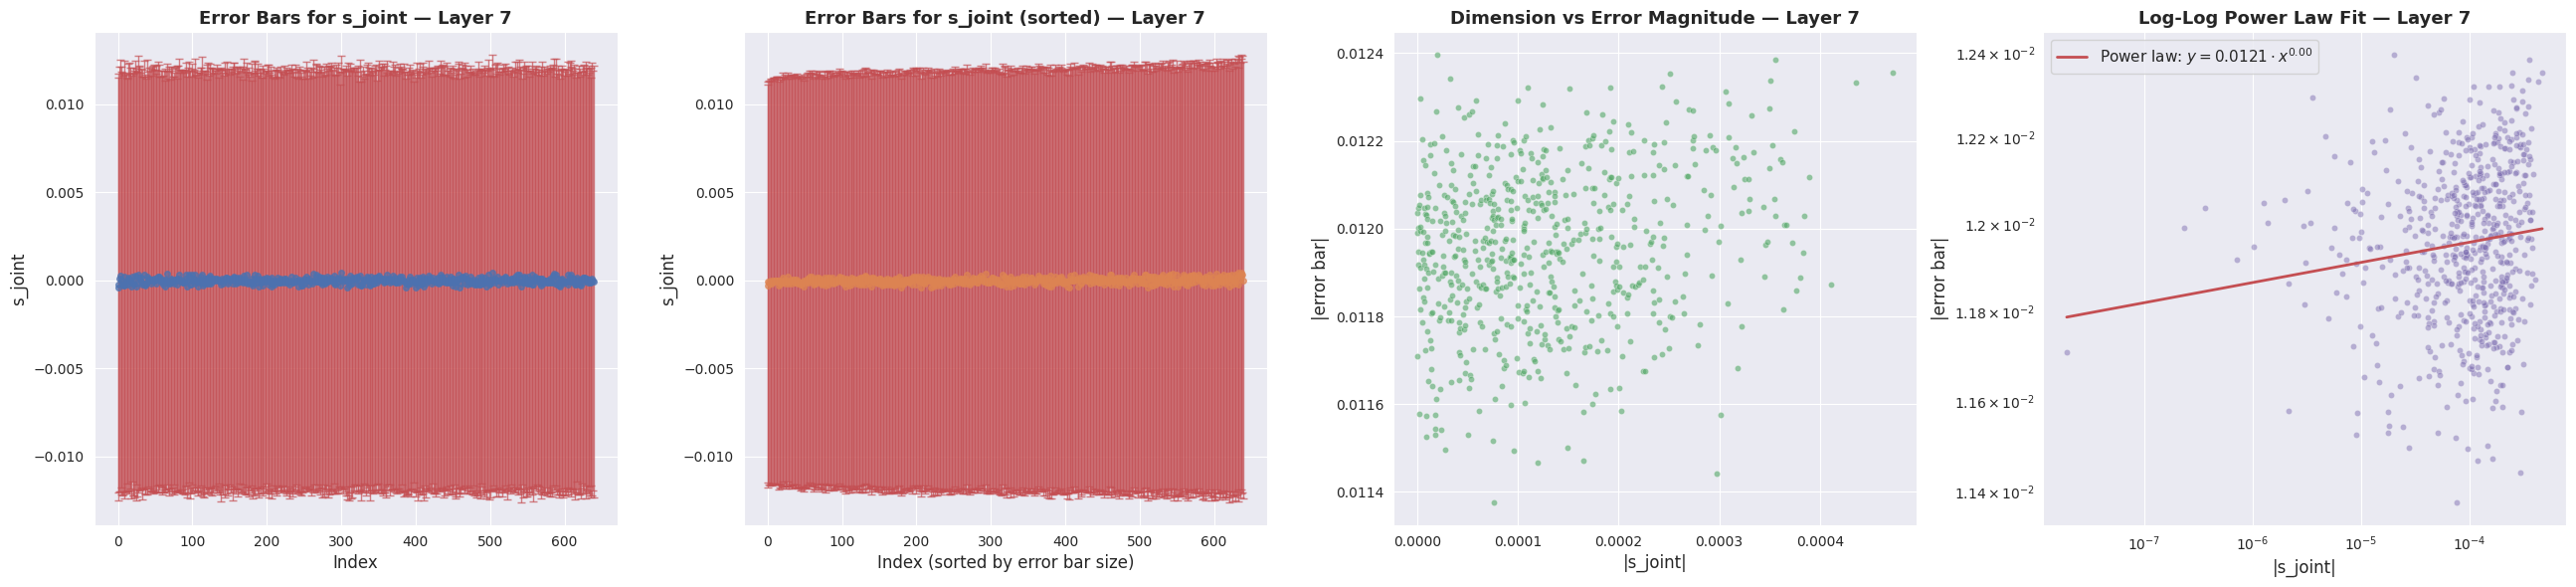

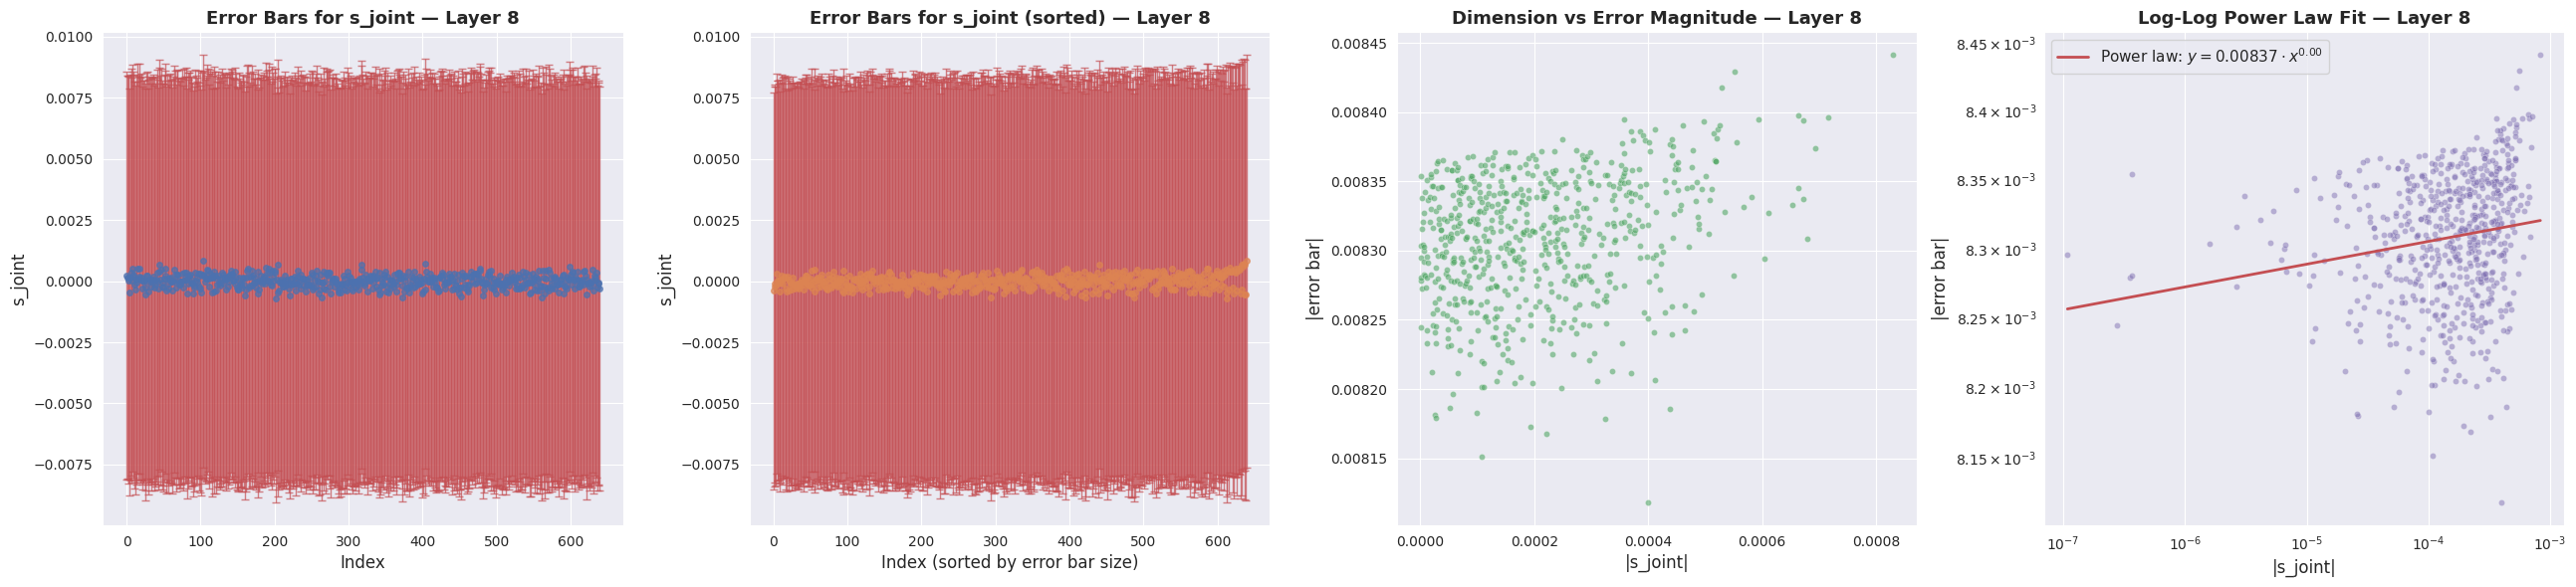

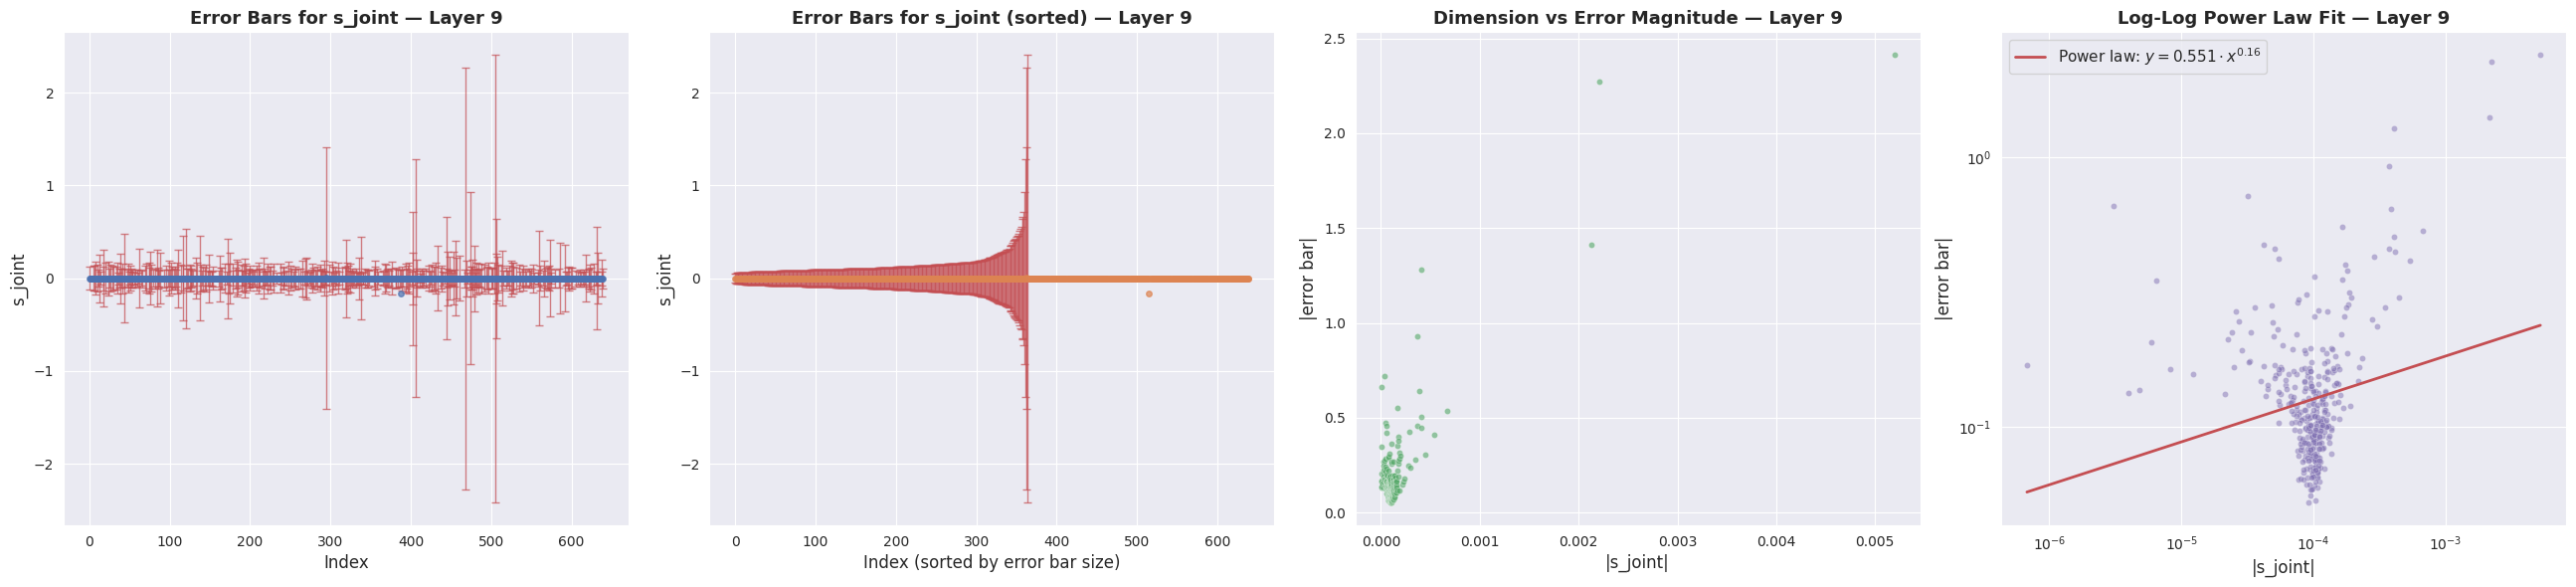

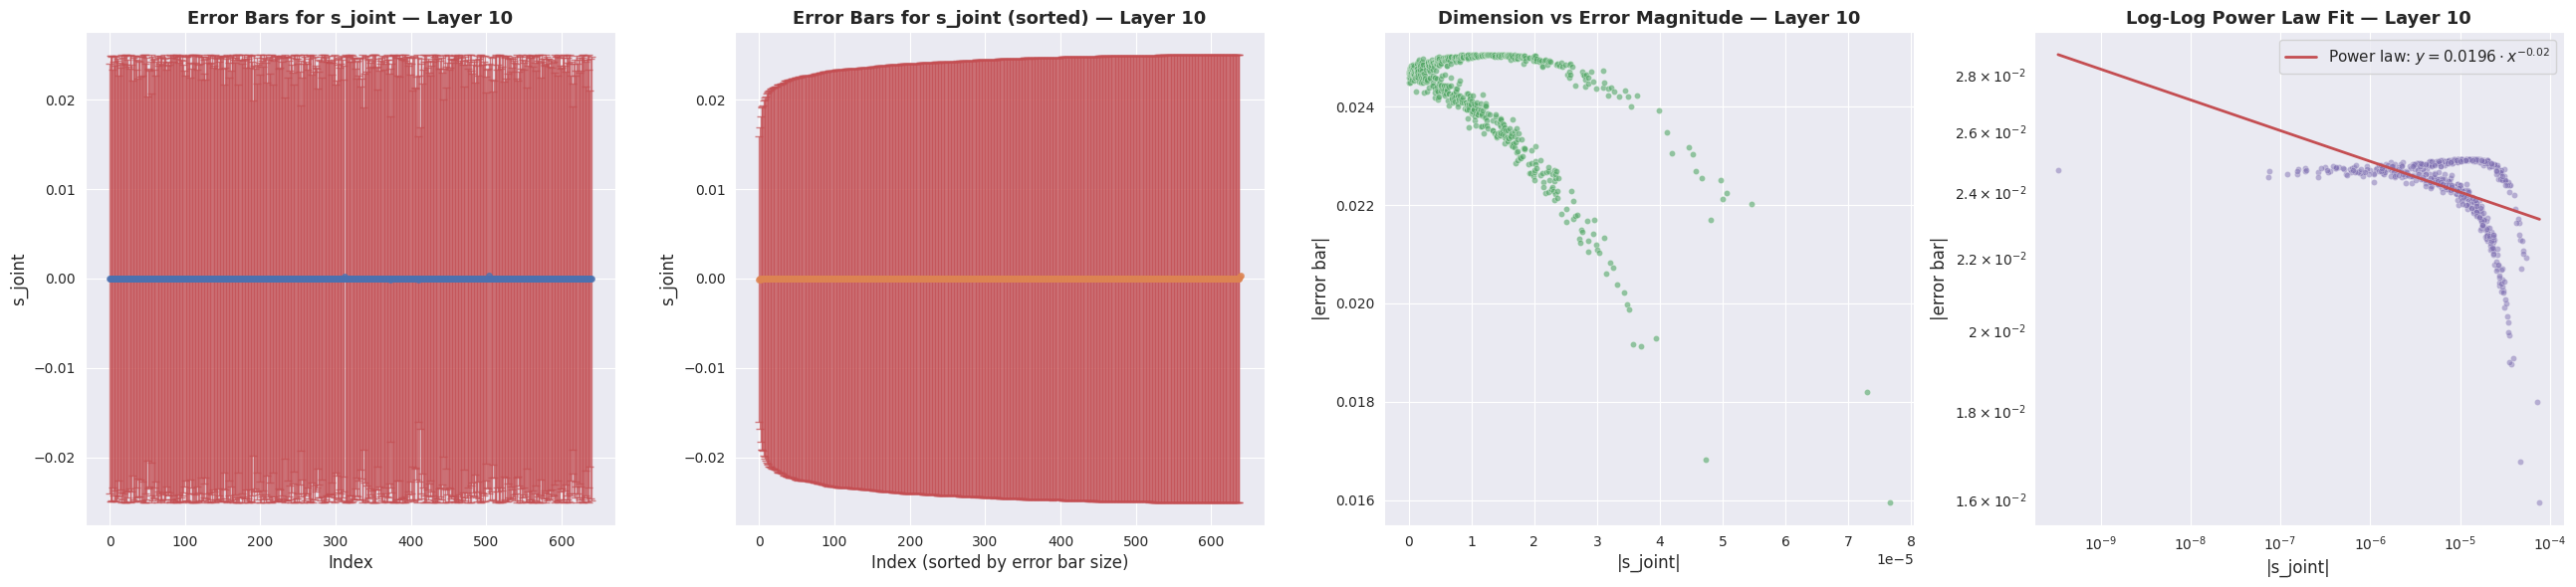

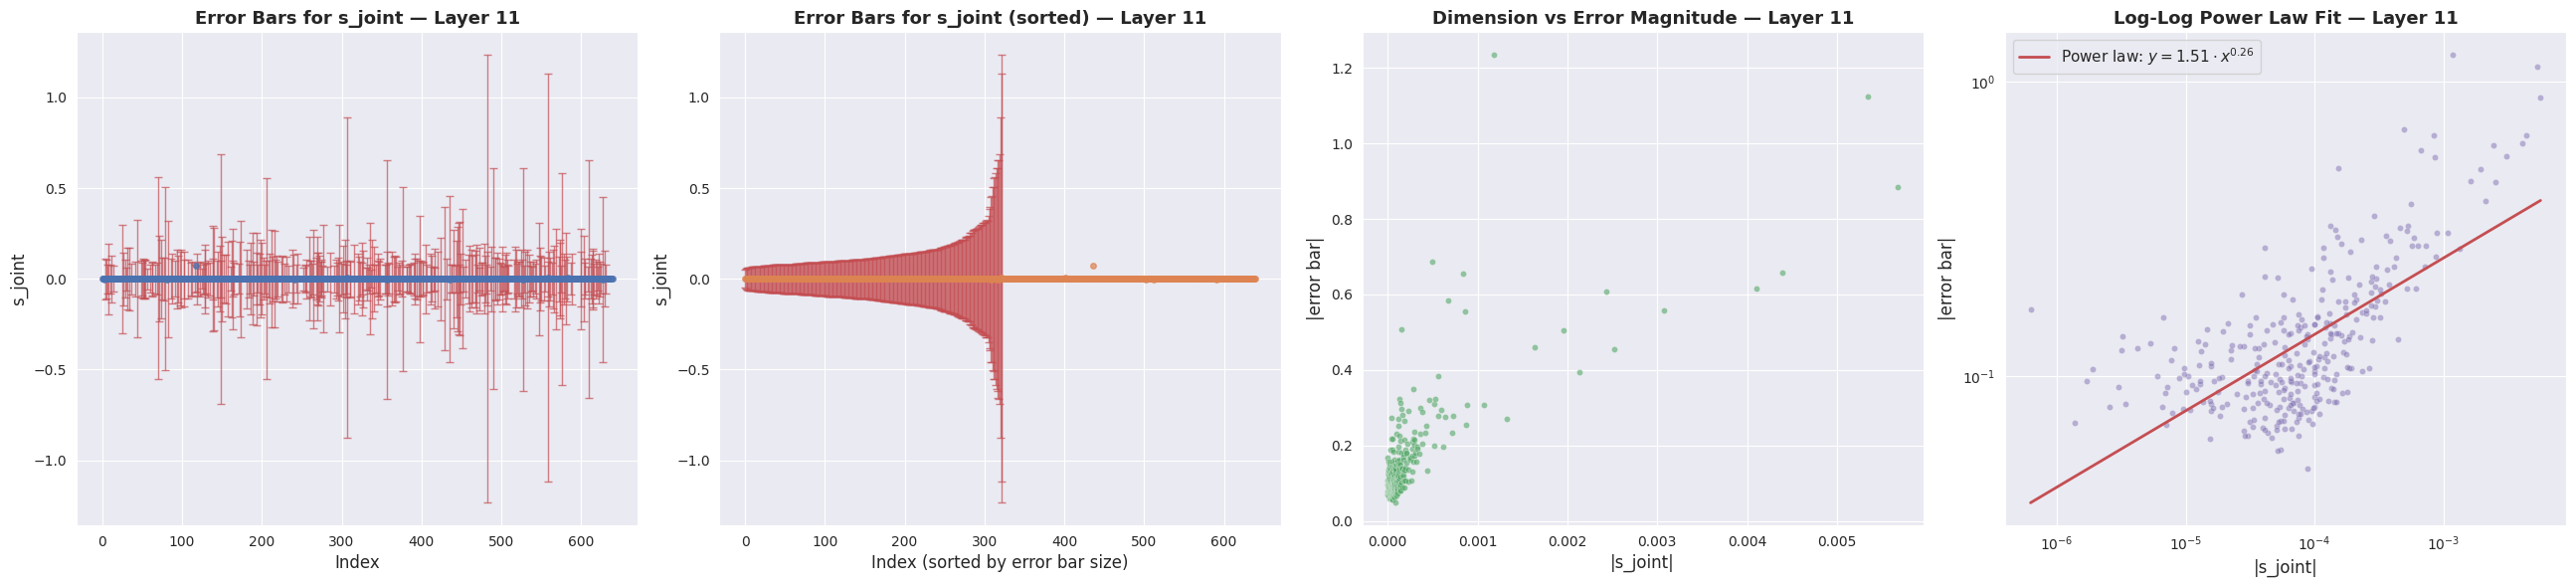

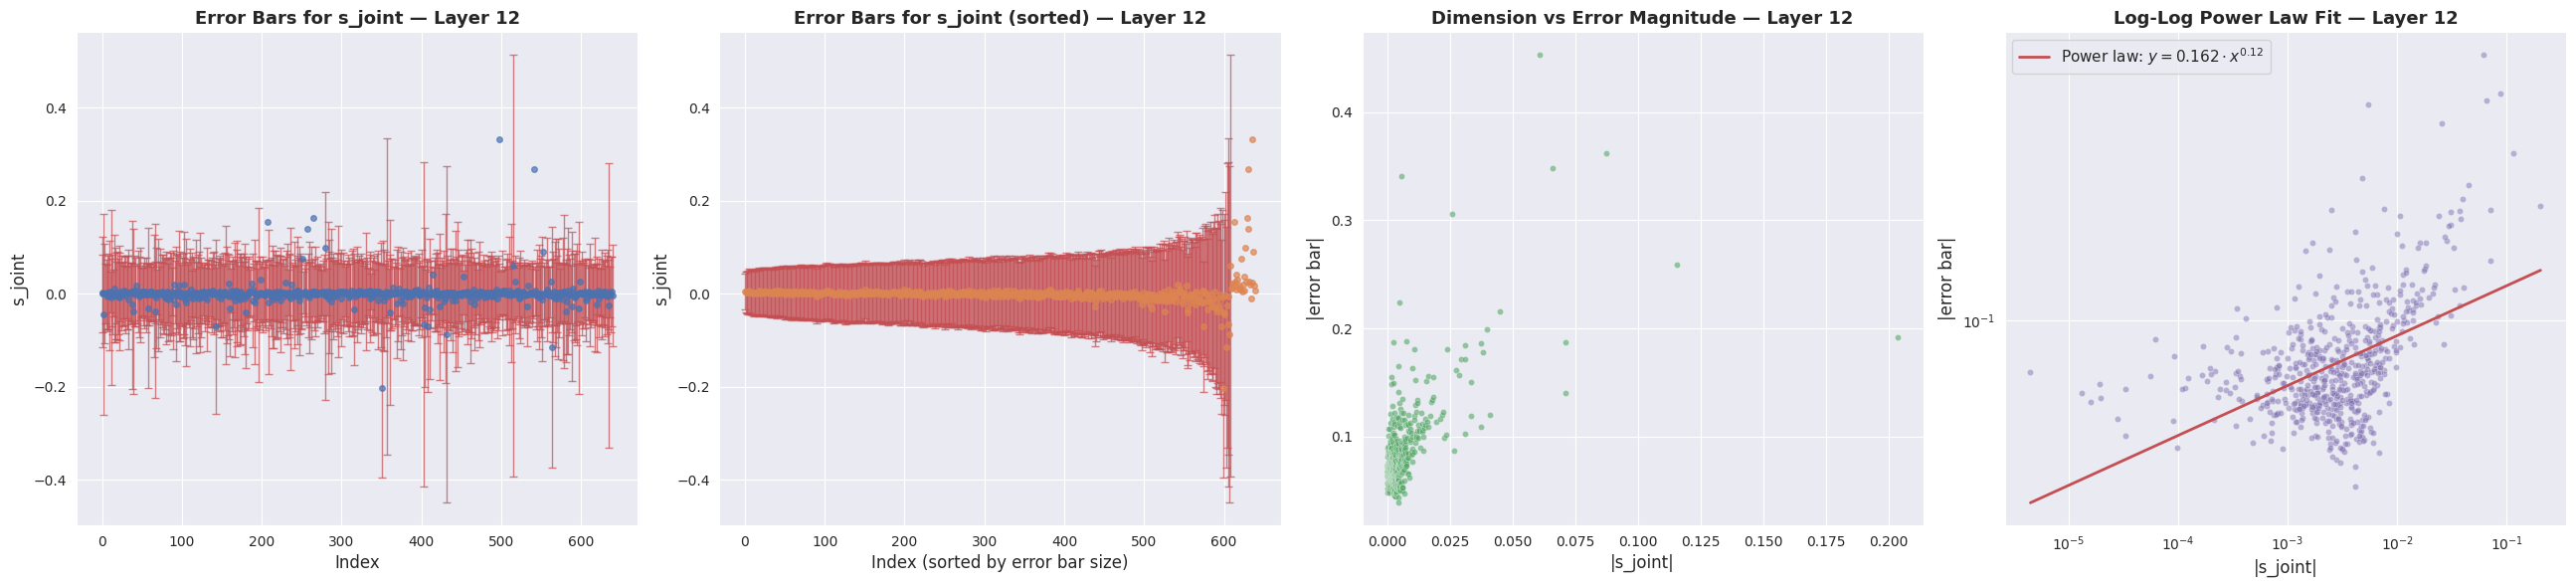

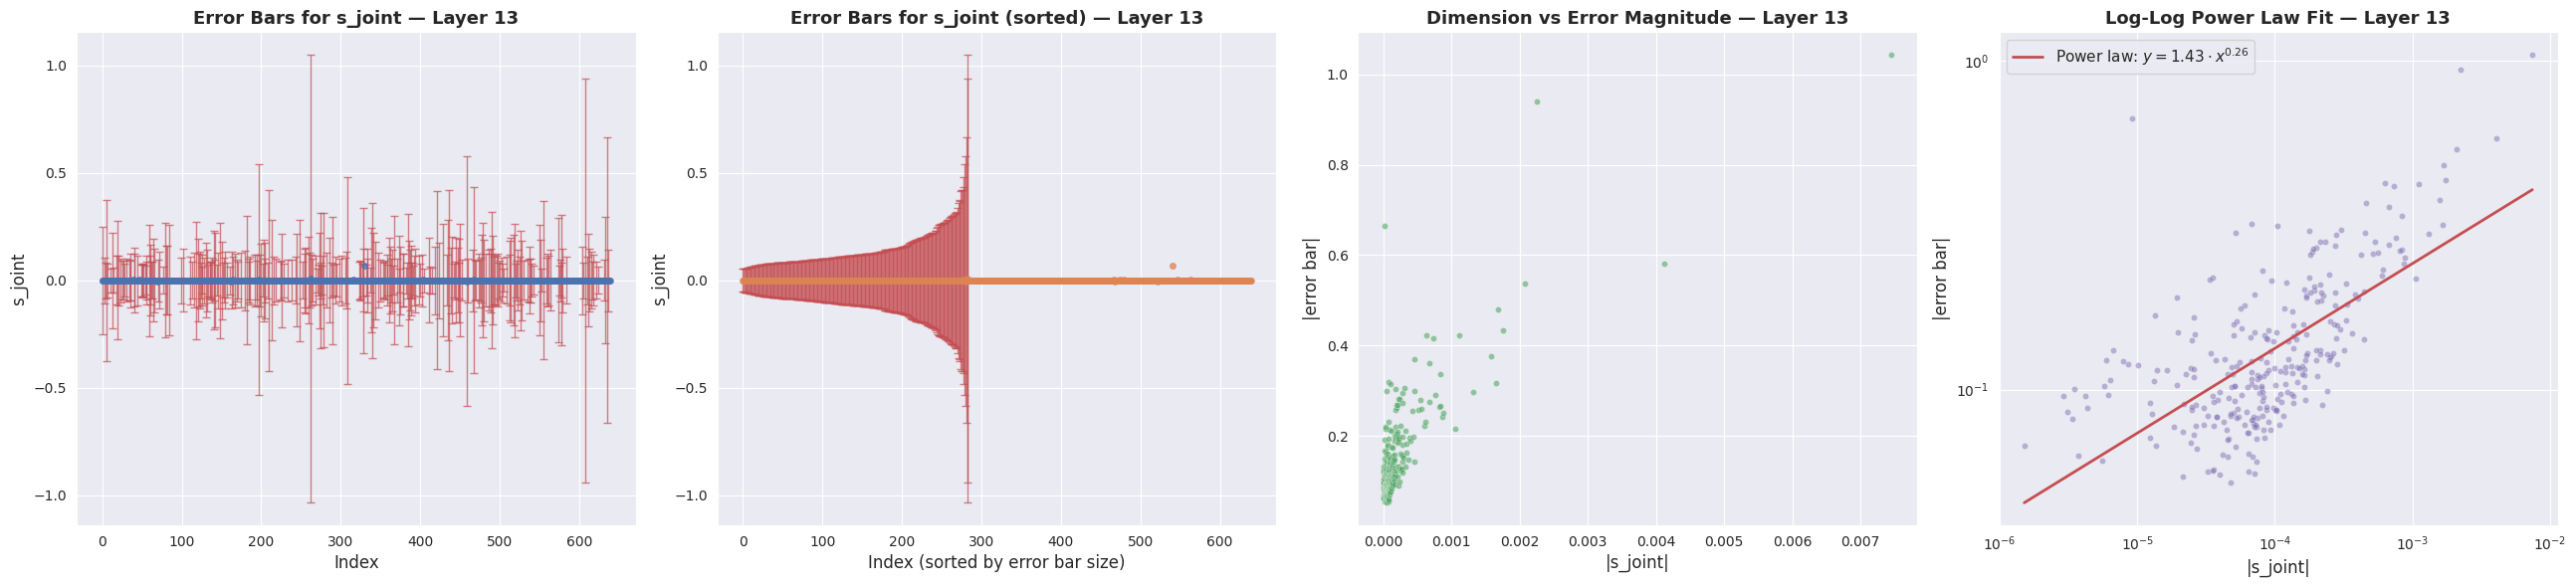

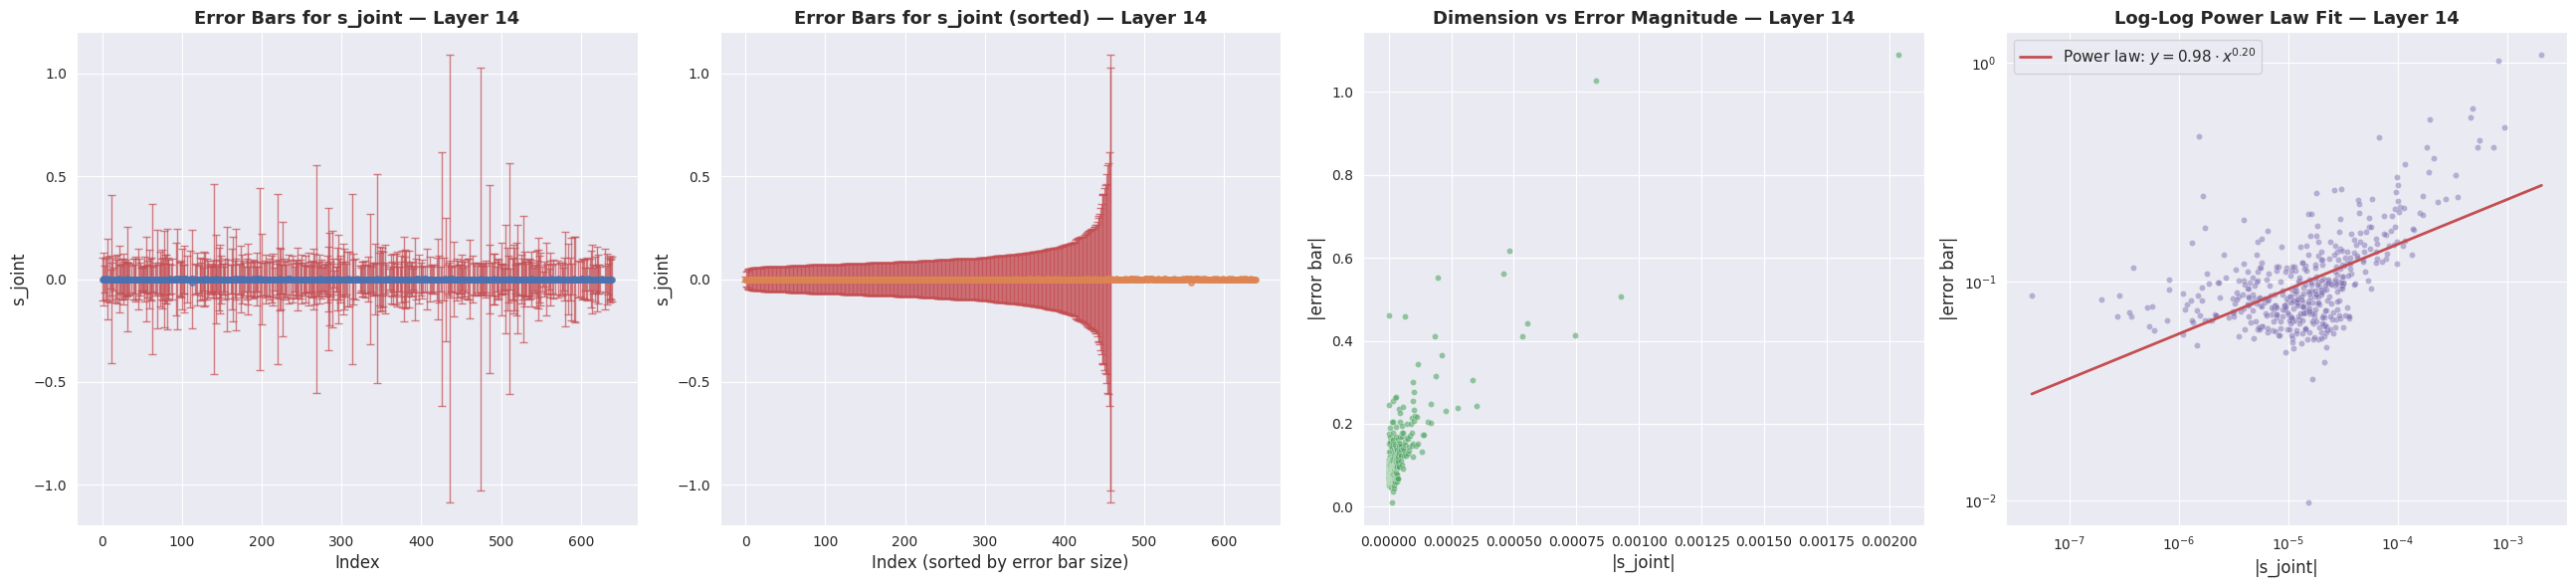

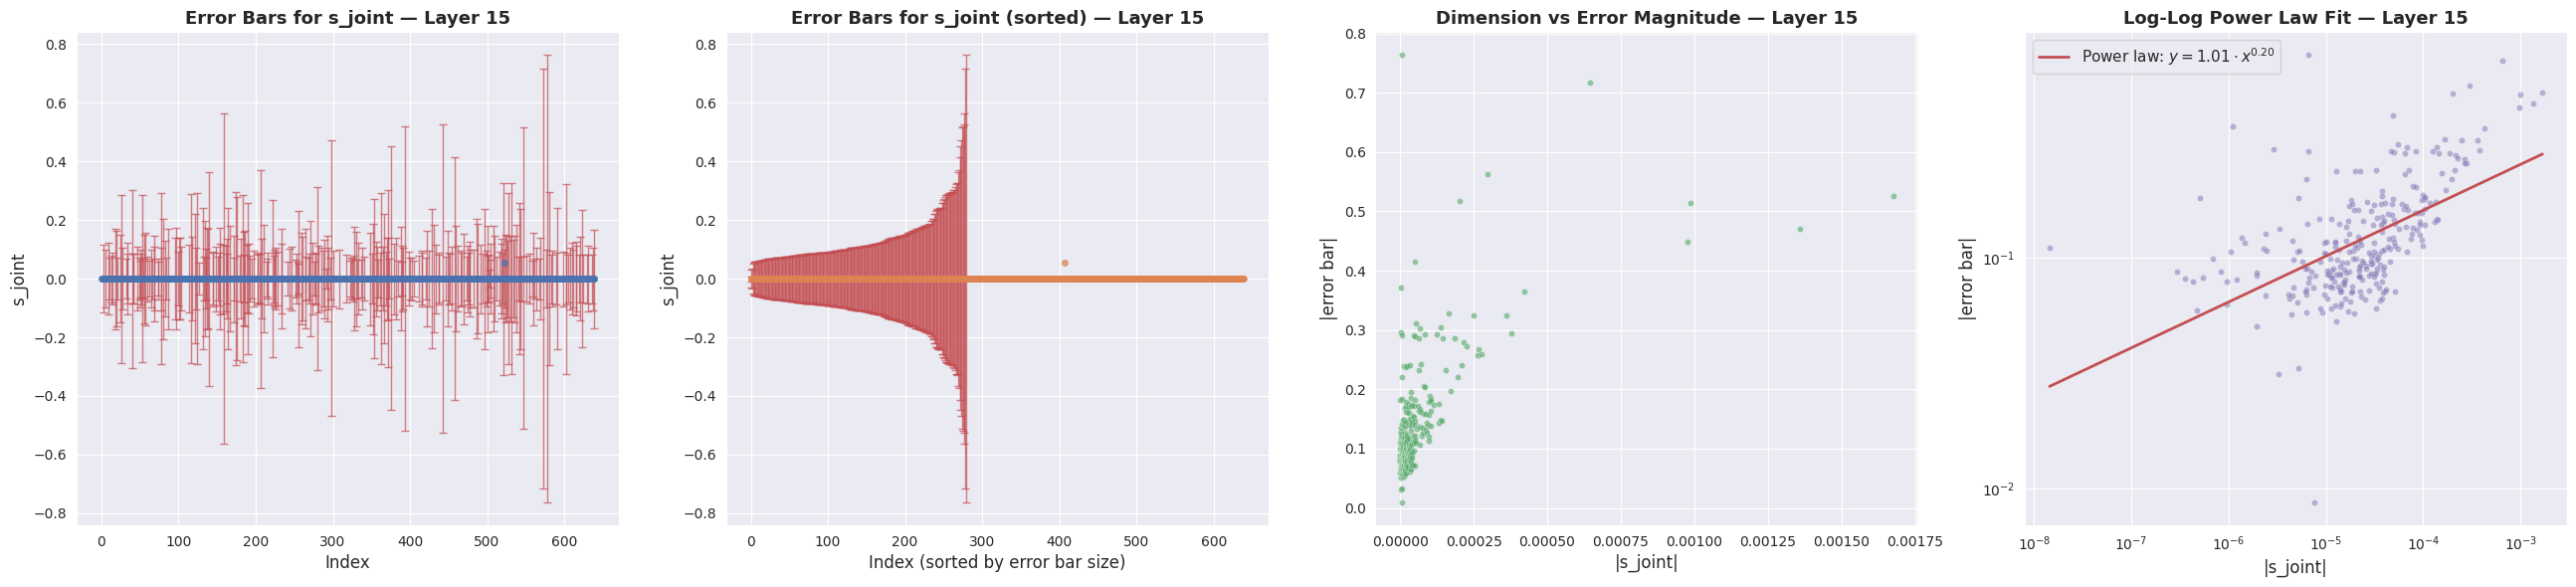

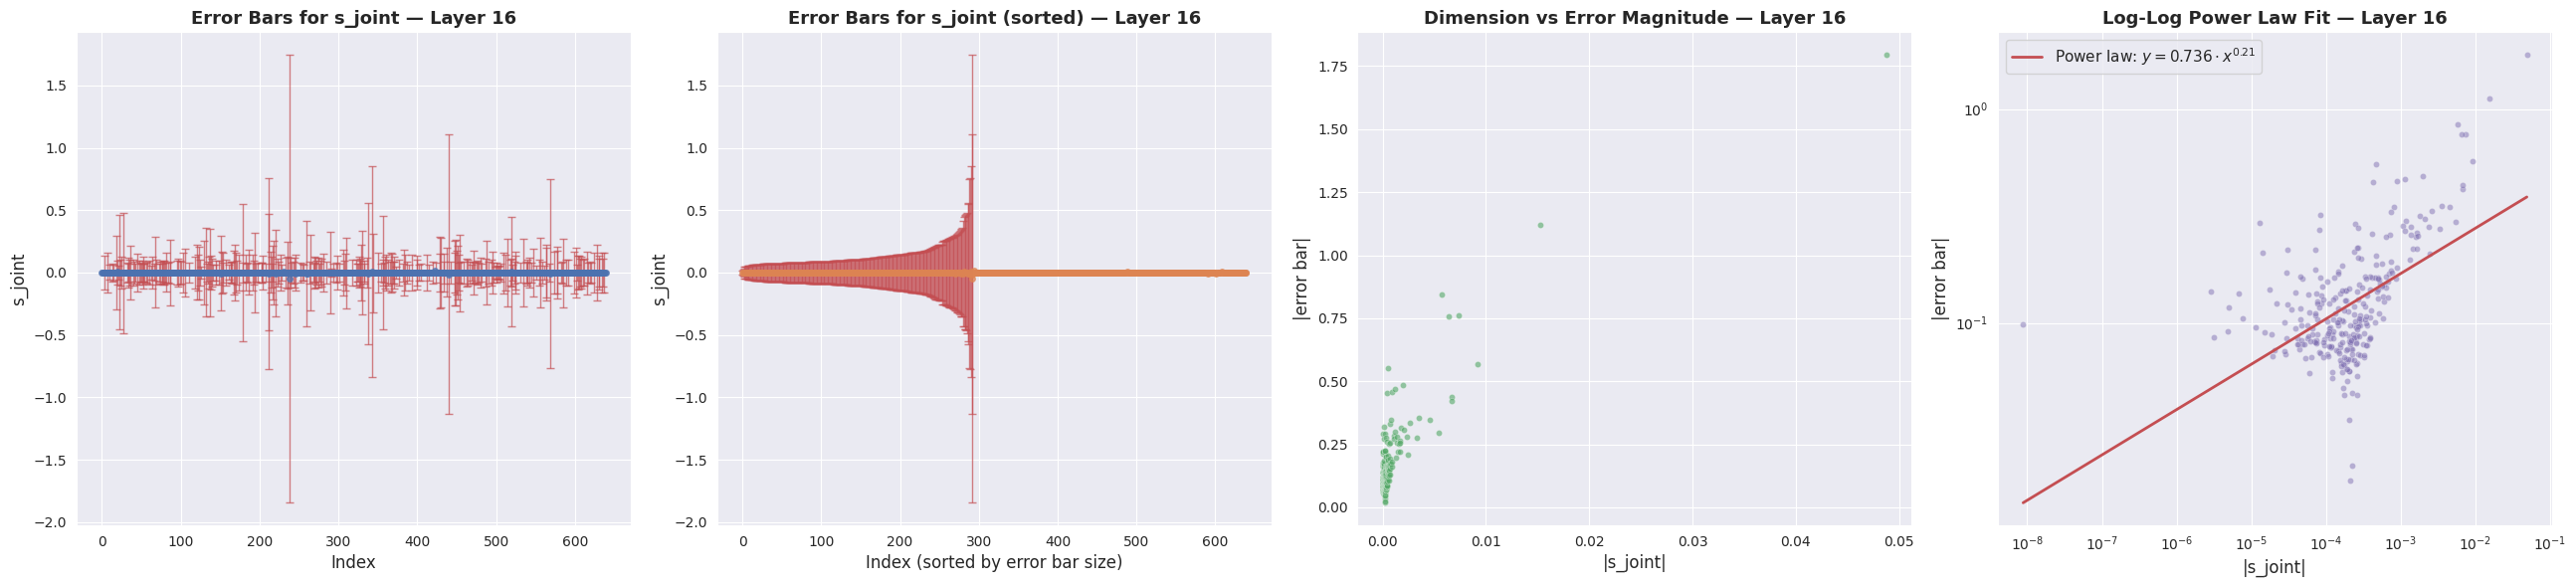

FileNotFoundError: [Errno 2] No such file or directory: '/net/dali/home/barton/dhw28/popDMS/esmDMS/esm_sim_saves/n_rep_error_bars_layer17.pkl'

In [21]:
for layer in range(31):
    plot_layer_error_data(layer, dataname="n_rep_error_bars")

In [ ]:
# test